In [1]:
import os
import io
import time
import math
import random
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
from PIL import Image, ImageEnhance
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import joblib
import tempfile

import os, warnings
# Tell loky how many cores to use so it won't call `wmic`
os.environ["LOKY_MAX_CPU_COUNT"] = str(os.cpu_count() or 1)

# (Optional) silence this specific warning completely
warnings.filterwarnings(
    "ignore",
    message="Could not find the number of physical cores",
    category=UserWarning
)


# ---------------------------
# Configuration
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Windows paths (use raw strings)
NONCRACK_DIR = r"C:\Users\Rehab Jadallah\Desktop\SD_Crack_Classification\Concrete_Crack\0_Non_Crack"
CRACK_DIR = r"C:\Users\Rehab Jadallah\Desktop\SD_Crack_Classification\Concrete_Crack\1_Crack"

IMG_SIZE = (128, 128)
USE_GRAYSCALE = True     # set False to use RGB (much higher dimensional)
AUG_PER_IMAGE = 6        # how many augmented samples per training image (0 to disable); more = better generalization
TEST_SIZE = 0.20
MAX_SKLEARN_PER_CLASS = 1500  # cap per-class for sklearn (SVM can't scale to 18k)

In [2]:
# ---------------------------
# Utilities
# ---------------------------
def is_image_file(p: Path) -> bool:
    return p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def load_and_preprocess(path: Path, img_size: Tuple[int, int], grayscale: bool = True) -> np.ndarray:
    """Load an image file and return a flattened numpy array after resizing (and grayscale if chosen)."""
    with Image.open(path) as img:
        # Convert
        if grayscale:
            img = img.convert("L")
        else:
            img = img.convert("RGB")
        # Resize with high-quality resampling
        img = img.resize(img_size, Image.BICUBIC)
        arr = np.asarray(img, dtype=np.float32)
        # Normalize to [0,1]
        arr = arr / 255.0
        # Flatten
        return arr.flatten()

def augment_pil(img: Image.Image) -> Image.Image:
    """Apply a random but mild augmentation to a PIL Image and return an augmented PIL Image."""
    # Random horizontal flip
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    # Small rotation (-10° to 10°)
    angle = random.uniform(-10, 10)
    img = img.rotate(angle, resample=Image.BICUBIC, expand=False, fillcolor=0 if img.mode == "L" else (0, 0, 0))
    # Slight translation (±5% of size)
    tx = int(random.uniform(-0.05, 0.05) * img.width)
    ty = int(random.uniform(-0.05, 0.05) * img.height)
    img = img.transform(img.size, Image.AFFINE, (1, 0, tx, 0, 1, ty), resample=Image.BICUBIC, fillcolor=0 if img.mode == "L" else (0, 0, 0))
    # Brightness jitter (0.8–1.2)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    return img

def pil_from_array_feature(x: np.ndarray, img_size: Tuple[int, int], grayscale: bool) -> Image.Image:
    """Reconstruct a PIL Image from feature vector for augmentation previews (used only on training set)."""
    if grayscale:
        arr = (x.reshape(img_size) * 255.0).clip(0, 255).astype(np.uint8)
        return Image.fromarray(arr, mode="L")
    else:
        c = 3
        arr = (x.reshape(img_size[1], img_size[0], c) * 255.0).clip(0, 255).astype(np.uint8)
        return Image.fromarray(arr, mode="RGB")

def model_size_kb(model) -> float:
    import io, joblib
    buf = io.BytesIO()
    joblib.dump(model, buf, compress=3)
    return len(buf.getvalue()) / 1024.0

def avg_inference_time_ms(model, X: np.ndarray) -> float:
    """Average per-image inference time in milliseconds."""
    # Measure single-sample prediction time to be comparable across models
    start = time.perf_counter()
    for i in range(X.shape[0]):
        _ = model.predict(X[i:i+1])
    elapsed = time.perf_counter() - start
    return (elapsed / X.shape[0]) * 1000.0

In [10]:
# ---------------------------
# Load dataset (capped per class for sklearn scalability)
# ---------------------------
def load_dataset(noncrack_dir: str, crack_dir: str, img_size: Tuple[int, int],
                 grayscale: bool, max_per_class: int = None) -> Tuple[np.ndarray, np.ndarray]:
    X, y = [], []
    for label, folder in [(0, noncrack_dir), (1, crack_dir)]:
        paths = [p for p in Path(folder).rglob("*") if p.is_file() and is_image_file(p)]
        if max_per_class:
            random.shuffle(paths)
            paths = paths[:max_per_class]
        for p in paths:
            try:
                feat = load_and_preprocess(p, img_size, grayscale=grayscale)
                X.append(feat)
                y.append(label)
            except Exception as e:
                print(f"[WARN] Skipped {p}: {e}")
    X = np.vstack(X).astype(np.float32)
    y = np.array(y, dtype=np.int64)
    return X, y

print(f"Loading images (max {MAX_SKLEARN_PER_CLASS} per class for sklearn baseline)...")
X, y = load_dataset(NONCRACK_DIR, CRACK_DIR, IMG_SIZE, USE_GRAYSCALE,
                    max_per_class=MAX_SKLEARN_PER_CLASS)
print(f"Loaded {X.shape[0]} images. Feature dim = {X.shape[1]}")


Loading images (max 1500 per class for sklearn baseline)...
Loaded 3000 images. Feature dim = 16384


In [11]:
# ---------------------------
# Train/test split
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

In [12]:
# ---------------------------
# Data augmentation on training set
# ---------------------------
if AUG_PER_IMAGE > 0:
    print(f"Augmenting training data (x{AUG_PER_IMAGE})...")
    aug_features = []
    aug_labels = []
    # Reconstruct minimal PIL image from features for augmentation
    for xi, yi in zip(X_train, y_train):
        img = pil_from_array_feature(xi, IMG_SIZE, USE_GRAYSCALE)
        for _ in range(AUG_PER_IMAGE):
            aug_img = augment_pil(img.copy())
            aug_img = aug_img.resize(IMG_SIZE, Image.BICUBIC)
            arr = np.asarray(aug_img, dtype=np.float32) / 255.0
            aug_features.append(arr.flatten())
            aug_labels.append(yi)
    if aug_features:
        X_aug = np.vstack(aug_features).astype(np.float32)
        y_aug = np.array(aug_labels, dtype=np.int64)
        X_train = np.vstack([X_train, X_aug])
        y_train = np.concatenate([y_train, y_aug])
        print(f"Training set after augmentation: {X_train.shape[0]} samples")

Augmenting training data (x6)...
Training set after augmentation: 16800 samples


In [13]:
# ---------------------------
# Define models
# ---------------------------
models: Dict[str, Pipeline] = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("clf", LogisticRegression(
            solver="saga", penalty="l2", max_iter=5000, random_state=SEED, n_jobs=-1))
    ]),
    "SVM_RBF": Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("clf", SVC(kernel="rbf", probability=False, random_state=SEED))
    ]),
    "DecisionTree": Pipeline([
        ("scaler", "passthrough"),
        ("clf", DecisionTreeClassifier(max_depth=None, random_state=SEED))
    ]),
    "RandomForest": Pipeline([
        ("scaler", "passthrough"),
        ("clf", RandomForestClassifier(
            n_estimators=300, max_depth=None, n_jobs=-1, random_state=SEED))
    ]),
    "KNN_k5": Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("clf", KNeighborsClassifier(n_neighbors=5, weights="distance"))
    ]),
    "MLP_1x256": Pipeline([
        ("scaler", StandardScaler(with_mean=True)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(256,), activation="relu", solver="adam",
            learning_rate_init=1e-3, max_iter=200, random_state=SEED, early_stopping=True))
    ]),
}

In [ ]:
# ---------------------------
# Train, evaluate, report
# ---------------------------
def evaluate_model(name: str, pipe: Pipeline, X_train: np.ndarray, y_train: np.ndarray,
                   X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
    print(f"\n=== Training {name} ===")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="binary", zero_division=0)
    rec = recall_score(y_test, y_pred, average="binary", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="binary", zero_division=0)

    # Inference latency
    inf_ms = avg_inference_time_ms(pipe, X_test)

    # Model size
    size_kb = model_size_kb(pipe)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "inference_ms_per_image": inf_ms,
        "model_size_kb": size_kb
    }

results = {}
for name, pipe in models.items():
    metrics = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
    results[name] = metrics


=== Training LogisticRegression ===


In [ ]:
# ---------------------------
# Print results in a table
# ---------------------------
def nice(num, digits=4):
    if isinstance(num, (int, np.integer)):
        return str(num)
    return f"{num:.{digits}f}"

headers = ["Model", "Accuracy", "Precision", "Recall", "F1", "ms/img", "Size (KB)"]
col_widths = [max(len(h), 14) for h in headers]

def print_row(cols):
    print(" | ".join(str(c).ljust(w) for c, w in zip(cols, col_widths)))

print("\n\n===== Evaluation Results =====")
print_row(headers)
print("-" * (sum(col_widths) + 3 * (len(headers) - 1)))
for name, m in results.items():
    row = [
        name,
        nice(m["accuracy"]),
        nice(m["precision"]),
        nice(m["recall"]),
        nice(m["f1"]),
        nice(m["inference_ms_per_image"]),
        nice(m["model_size_kb"])
    ]
    print_row(row)



===== Evaluation Results =====
Model          | Accuracy       | Precision      | Recall         | F1             | ms/img         | Size (KB)     
--------------------------------------------------------------------------------------------------------------------
LogisticRegression | 0.5714         | 1.0000         | 0.1429         | 0.2500         | 0.2222         | 383.6641      
SVM_RBF        | 0.7500         | 1.0000         | 0.5000         | 0.6667         | 32.0647        | 19511.5928    
DecisionTree   | 0.7500         | 0.8889         | 0.5714         | 0.6957         | 0.0726         | 2.2920        
RandomForest   | 0.7500         | 0.8889         | 0.5714         | 0.6957         | 39.4401        | 349.4727      
KNN_k5         | 0.5357         | 1.0000         | 0.0714         | 0.1333         | 284.0511       | 19826.9873    
MLP_1x256      | 0.6786         | 0.8571         | 0.4286         | 0.5714         | 2.7826         | 46064.7031    


In [ ]:
# Optional: brief class balance check
unique, counts = np.unique(y, return_counts=True)
print("\nClass counts (full dataset):", dict(zip(unique.tolist(), counts.tolist())))
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])
print("Done.")


Class counts (full dataset): {0: 70, 1: 70}
Train size: 336  Test size: 28
Done.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# --- Random Forest config (match your earlier params if desired) ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=SEED,
    n_jobs=1  # use 1 to avoid loky/wmic warnings on Windows
)

# --- 5-fold Stratified CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Scoring: binary classification assumes class "1" is positive
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_results = cross_validate(
    rf, X, y,
    scoring=scoring,
    cv=cv,
    return_train_score=False,
    n_jobs=1  # parallelize if you've set LOKY_MAX_CPU_COUNT
)

# --- Print per-fold metrics ---
print("===== 5-Fold CV: Random Forest =====")
for i in range(cv.get_n_splits()):
    print(f"Fold {i+1}: "
          f"Acc={cv_results['test_accuracy'][i]:.4f}  "
          f"Prec={cv_results['test_precision'][i]:.4f}  "
          f"Rec={cv_results['test_recall'][i]:.4f}  "
          f"F1={cv_results['test_f1'][i]:.4f}")

# --- Print mean ± std ---
def mean_std(arr):
    return np.mean(arr), np.std(arr, ddof=1)

acc_m, acc_s = mean_std(cv_results['test_accuracy'])
pre_m, pre_s = mean_std(cv_results['test_precision'])
rec_m, rec_s = mean_std(cv_results['test_recall'])
f1_m,  f1_s  = mean_std(cv_results['test_f1'])

print("\nOverall (mean ± std):")
print(f"Accuracy : {acc_m:.4f} ± {acc_s:.4f}")
print(f"Precision: {pre_m:.4f} ± {pre_s:.4f}")
print(f"Recall   : {rec_m:.4f} ± {rec_s:.4f}")
print(f"F1-score : {f1_m:.4f} ± {f1_s:.4f}")

===== 5-Fold CV: Random Forest =====
Fold 1: Acc=0.6429  Prec=0.6667  Rec=0.5714  F1=0.6154
Fold 2: Acc=0.7857  Prec=1.0000  Rec=0.5714  F1=0.7273
Fold 3: Acc=0.5714  Prec=0.5833  Rec=0.5000  F1=0.5385
Fold 4: Acc=0.7143  Prec=0.8000  Rec=0.5714  F1=0.6667
Fold 5: Acc=0.5357  Prec=0.5263  Rec=0.7143  F1=0.6061

Overall (mean ± std):
Accuracy : 0.6500 ± 0.1023
Precision: 0.7153 ± 0.1896
Recall   : 0.5857 ± 0.0782
F1-score : 0.6308 ± 0.0707


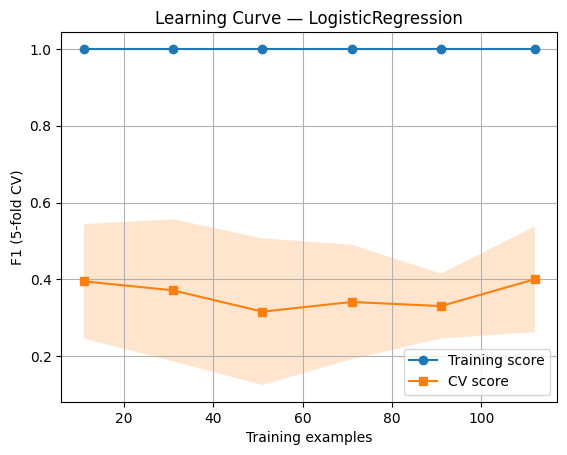

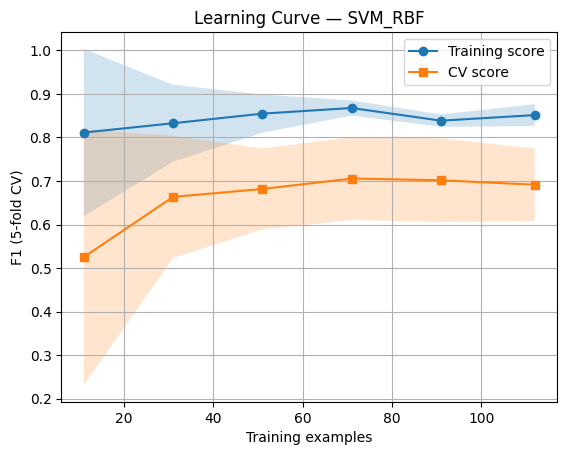

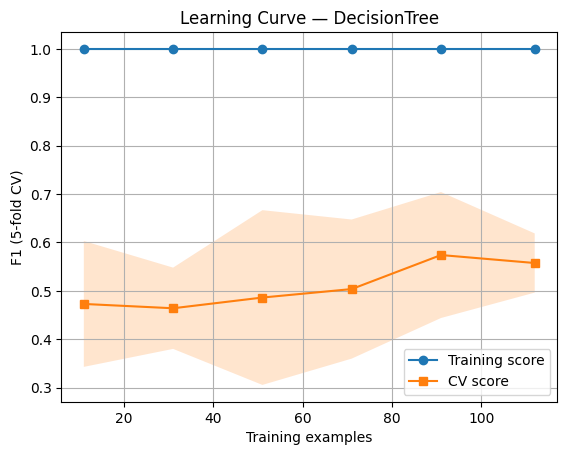

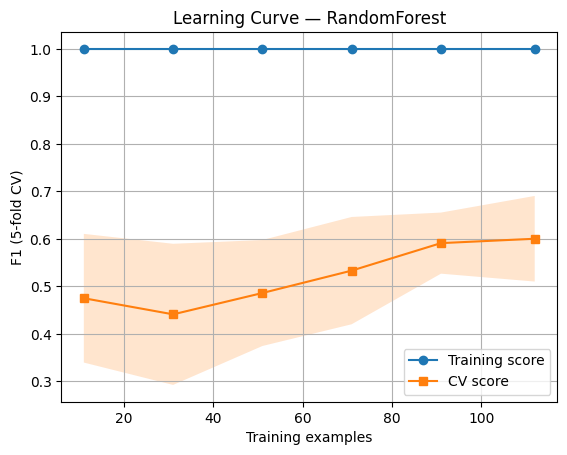

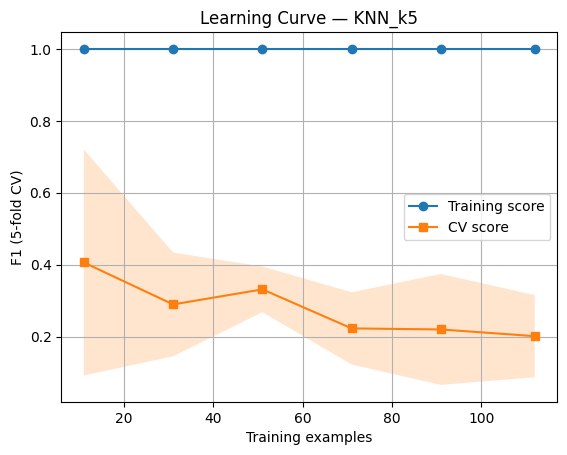

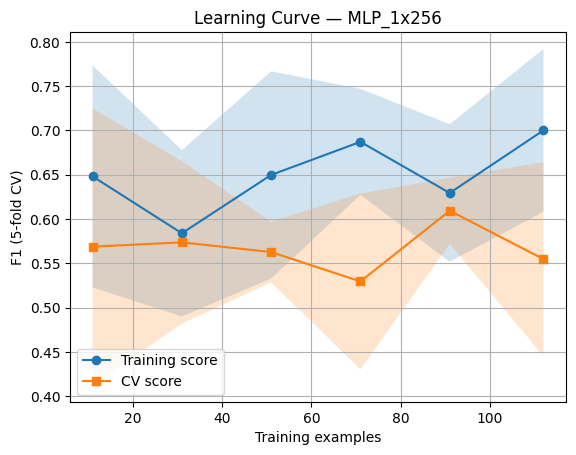

Training MLP once to capture loss curve...


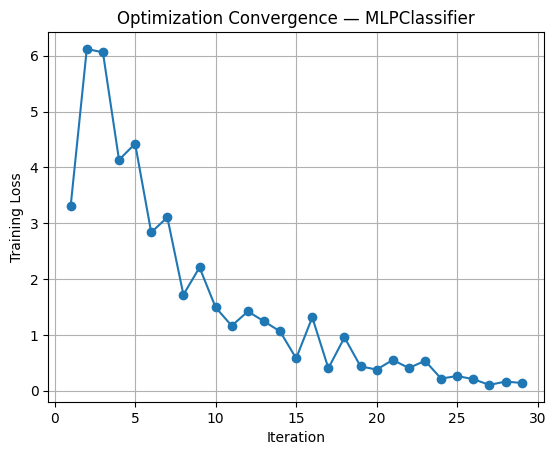


===== Hyperparameters (classifier step) =====

--- LogisticRegression ---
{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': None,
 'max_iter': 5000,
 'multi_class': 'deprecated',
 'n_jobs': -1,
 'penalty': 'l2',
 'random_state': 42,
 'solver': 'saga',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

--- SVM_RBF ---
{'C': 1.0,
 'break_ties': False,
 'cache_size': 200,
 'class_weight': None,
 'coef0': 0.0,
 'decision_function_shape': 'ovr',
 'degree': 3,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'probability': False,
 'random_state': 42,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

--- DecisionTree ---
{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter

In [ ]:
# --- Convergence (learning) curves for all models + training loss curve for MLP ---

from sklearn.model_selection import StratifiedKFold, learning_curve
import matplotlib.pyplot as plt

# CV settings (matches your earlier usage)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def plot_learning_curve_for_pipeline(name, pipe, X, y, cv, n_jobs=1):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y,
        cv=cv,
        n_jobs=n_jobs,
        scoring="f1",              # use F1 as a balanced signal; change to "accuracy" if you prefer
        train_sizes=np.linspace(0.1, 1.0, 6),
        shuffle=True,
        random_state=SEED
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1, ddof=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1, ddof=1)

    plt.figure()
    plt.title(f"Learning Curve — {name}")
    plt.xlabel("Training examples")
    plt.ylabel("F1 (5-fold CV)")
    # shaded std (no explicit colors per your tooling best practices)
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
    plt.fill_between(train_sizes, val_mean-val_std,     val_mean+val_std,     alpha=0.2)
    plt.plot(train_sizes, train_mean, marker="o", label="Training score")
    plt.plot(train_sizes, val_mean,   marker="s", label="CV score")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()

# Plot learning curves for every model in your dictionary
for name, pipe in models.items():
    # If you set the WMIC workaround earlier, you can raise n_jobs to speed this up
    plot_learning_curve_for_pipeline(name, pipe, X, y, cv=cv, n_jobs=1)

# --- True optimization (loss) convergence curve for the MLP only ---
if "MLP_1x256" in models:
    print("Training MLP once to capture loss curve...")
    mlp_pipe = models["MLP_1x256"]
    # Fit on the training split (not CV) to obtain the iterative loss trajectory
    mlp_pipe.fit(X_train, y_train)
    mlp = mlp_pipe.named_steps["clf"]
    if hasattr(mlp, "loss_curve_") and mlp.loss_curve_:
        plt.figure()
        plt.title("Optimization Convergence — MLPClassifier")
        plt.xlabel("Iteration")
        plt.ylabel("Training Loss")
        plt.plot(range(1, len(mlp.loss_curve_)+1), mlp.loss_curve_, marker="o")
        plt.grid(True)
        plt.show()
    else:
        print("[INFO] No loss_curve_ available (try increasing max_iter or disable early_stopping).")

# --- Print hyperparameters of each model (classifier step of the pipeline) ---

from pprint import pprint

def print_model_hyperparams(models_dict):
    print("\n===== Hyperparameters (classifier step) =====")
    for name, pipe in models_dict.items():
        clf = pipe.named_steps["clf"]
        print(f"\n--- {name} ---")
        # Keep it tidy: only the classifier's own params (not the entire pipeline)
        params = clf.get_params(deep=False)
        pprint(params)

print_model_hyperparams(models)

# MobileNetV2 Transfer Learning Model

**Why MobileNetV2?**
- Pre-trained on ImageNet — already understands edges, textures, and structural patterns
- Designed for mobile deployment: small, fast, and TFLite-native
- Two-phase training: freeze backbone → train head first, then fine-tune top layers

This section trains on the **full dataset (~18k images)** and replaces the scratch CNN.

In [3]:
# ---------------------------
# Install / verify TensorFlow
# ---------------------------
import subprocess, sys

try:
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__}")
except ImportError:
    print("Installing TensorFlow...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow"])
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__}")


TensorFlow 2.20.0


In [ ]:
# ---------------------------
# Load full dataset for CNN (streaming from disk — no RAM explosion)
# ---------------------------
import os, time
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score, roc_curve)

CNN_IMG_SIZE = (224, 224)   # MobileNetV2 native size
CNN_BATCH    = 32
DATA_DIR     = r"C:\Users\Rehab Jadallah\Desktop\SD_Crack_Classification\Concrete_Crack"

tf.random.set_seed(SEED)

full_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=CNN_IMG_SIZE,
    batch_size=CNN_BATCH,
    label_mode='binary',
    shuffle=True,
    seed=SEED
)

class_names = full_ds.class_names   # ['0_Non_Crack', '1_Crack']
print(f"Classes: {class_names}")

# Count labels for class-weight calculation
labels_all = np.concatenate([y.numpy() for _, y in full_ds.unbatch().batch(2000)])
n_neg = int(np.sum(labels_all == 0))
n_pos = int(np.sum(labels_all == 1))
total = n_neg + n_pos
print(f"Total images : {total:,}")
print(f"  Non-crack  : {n_neg:,}  ({n_neg/total*100:.1f}%)")
print(f"  Crack      : {n_pos:,}  ({n_pos/total*100:.1f}%)")

# Inverse-frequency class weights to handle imbalance
class_weight = {0: total / (2 * n_neg), 1: total / (2 * n_pos)}
print(f"Class weights: non-crack={class_weight[0]:.3f}, crack={class_weight[1]:.3f}")

# Split: 70% train / 15% val / 15% test  (by batch count)
n_batches = len(full_ds)
train_n = int(0.70 * n_batches)
val_n   = int(0.15 * n_batches)
test_n  = n_batches - train_n - val_n

train_ds_raw = full_ds.take(train_n)
val_ds_raw   = full_ds.skip(train_n).take(val_n)
test_ds_raw  = full_ds.skip(train_n + val_n)

# MobileNetV2 preprocessing: [0,255] -> [-1, 1]
preprocess_input = keras.applications.mobilenet_v2.preprocess_input

augment = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.15),
    keras.layers.RandomZoom(0.15),
    keras.layers.RandomBrightness(0.15),
    keras.layers.RandomContrast(0.15),
], name="augmentation")

def prepare_train(images, labels):
    images = augment(images, training=True)
    return preprocess_input(images), labels

def prepare_eval(images, labels):
    return preprocess_input(images), labels

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.map(prepare_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds_raw.map(prepare_eval,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(prepare_eval,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print(f"\nBatches -> train={train_n}, val={val_n}, test={test_n}")


In [ ]:
# Pre-download MobileNetV2 ImageNet weights (~9 MB) so cell below does not hang on a slow/stuck fetch.
# Run this once if `keras.applications.MobileNetV2(..., weights="imagenet")` stalls.
import urllib.request
import os

url = "https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5"
save_path = os.path.join(
    os.path.expanduser("~"),
    ".keras",
    "models",
    "mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_224_no_top.h5",
)
os.makedirs(os.path.dirname(save_path), exist_ok=True)

if os.path.isfile(save_path) and os.path.getsize(save_path) > 1_000_000:
    print("Weights already present:", save_path)
else:
    print("Downloading weights to", save_path, "...")
    urllib.request.urlretrieve(url, save_path)
    print("Done.")


In [ ]:
# ---------------------------
# Build MobileNetV2 model
# ---------------------------
tf.random.set_seed(SEED)

base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze for Phase 1

inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = keras.layers.GlobalAveragePooling2D()(x)
x       = keras.layers.Dropout(0.3)(x)
x       = keras.layers.Dense(128, activation='relu')(x)
x       = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(1, activation='sigmoid')(x)

model = keras.Model(inputs, outputs, name="CrackDetector_MobileNetV2")
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc'),
    ]
)

total_params     = model.count_params()
trainable_params = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Total params    : {total_params:,}")
print(f"Trainable (P1)  : {trainable_params:,}  (backbone frozen)")


In [ ]:
# ---------------------------
# Phase 1: Train classification head (backbone frozen)
# ---------------------------
print("===== Phase 1: Training Classification Head =====")
print("Backbone frozen — only the dense head learns.\n")

callbacks_p1 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=3, min_lr=1e-6, verbose=1),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks_p1,
    verbose=1,
)

p1_best_acc = max(history1.history['val_accuracy'])
print(f"\nPhase 1 best val accuracy: {p1_best_acc:.4f}")


In [ ]:
# ---------------------------
# Phase 2: Fine-tune top layers of MobileNetV2
# ---------------------------
print("===== Phase 2: Fine-tuning Top Layers =====")

# Unfreeze top 40 layers of the backbone, keep lower layers frozen
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

trainable_p2 = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Trainable params (Phase 2): {trainable_p2:,}")

# Much lower LR to avoid destroying pre-trained weights
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc'),
    ]
)

callbacks_p2 = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=8,
                                   restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                       patience=4, min_lr=1e-8, verbose=1),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=callbacks_p2,
    verbose=1,
)

p2_best_acc = max(history2.history['val_accuracy'])
print(f"\nPhase 2 best val accuracy: {p2_best_acc:.4f}")


In [ ]:
# ---------------------------
# Evaluate on test set + generate poster-ready figures
# ---------------------------
POSTER_DIR = "poster_figures"
os.makedirs(POSTER_DIR, exist_ok=True)

# Collect predictions on held-out test set
y_true_list, y_prob_list = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_prob_list.extend(probs.flatten().tolist())
    y_true_list.extend(labels.numpy().flatten().tolist())

y_true = np.array(y_true_list)
y_prob = np.array(y_prob_list)
y_pred = (y_prob >= 0.5).astype(int)

cnn_accuracy  = accuracy_score(y_true, y_pred)
cnn_precision = precision_score(y_true, y_pred, zero_division=0)
cnn_recall    = recall_score(y_true, y_pred, zero_division=0)
cnn_f1        = f1_score(y_true, y_pred, zero_division=0)
cnn_auc       = roc_auc_score(y_true, y_prob)

print("=" * 52)
print("MobileNetV2 Test Set Results")
print("=" * 52)
print(f"  Accuracy : {cnn_accuracy:.4f}  ({cnn_accuracy*100:.1f}%)")
print(f"  Precision: {cnn_precision:.4f}")
print(f"  Recall   : {cnn_recall:.4f}")
print(f"  F1-score : {cnn_f1:.4f}")
print(f"  AUC-ROC  : {cnn_auc:.4f}")
print("=" * 52)

# ── Figure 1: Confusion Matrix ──────────────────────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Non-Crack', 'Crack'], fontsize=12)
ax.set_yticklabels(['Non-Crack', 'Crack'], fontsize=12)
ax.set_xlabel('Predicted', fontsize=13); ax.set_ylabel('Actual', fontsize=13)
ax.set_title(
    f'Confusion Matrix\nAccuracy {cnn_accuracy*100:.1f}%  |  AUC {cnn_auc:.3f}',
    fontsize=12
)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=16, color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(f"{POSTER_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.close()
print("Saved: confusion_matrix.png")

# ── Figure 2: ROC Curve ─────────────────────────────────────
fpr, tpr, _ = roc_curve(y_true, y_prob)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, lw=2, label=f'MobileNetV2 (AUC = {cnn_auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13)
ax.legend(fontsize=11); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{POSTER_DIR}/roc_curve.png", dpi=150, bbox_inches='tight')
plt.close()
print("Saved: roc_curve.png")

# ── Figure 3: Training curves (Phase 1 + Phase 2) ───────────
acc_all      = history1.history['accuracy']     + history2.history['accuracy']
val_acc_all  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss_all     = history1.history['loss']         + history2.history['loss']
val_loss_all = history1.history['val_loss']     + history2.history['val_loss']
p1_end       = len(history1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tr, vl, title, ylabel in [
    (axes[0], acc_all,  val_acc_all,  'Accuracy', 'Accuracy'),
    (axes[1], loss_all, val_loss_all, 'Loss',     'Loss'),
]:
    ep = range(1, len(tr) + 1)
    ax.plot(ep, tr, label='Train')
    ax.plot(ep, vl, label='Validation')
    ax.axvline(p1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune start')
    ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13); ax.legend(fontsize=10); ax.grid(True, alpha=0.4)
plt.suptitle('MobileNetV2 Training History (Phase 1 + Phase 2)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{POSTER_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.close()
print("Saved: training_curves.png")

# ── Figure 4: Model comparison bar chart ────────────────────
model_labels = list(results.keys()) + ['MobileNetV2']
model_accs   = [results[k]['accuracy'] for k in results] + [cnn_accuracy]
model_f1s    = [results[k]['f1']       for k in results] + [cnn_f1]

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(model_labels))
w = 0.35
bars1 = ax.bar(x - w/2, model_accs, w, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + w/2, model_f1s,  w, label='F1-Score',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(model_labels, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Comparison: Classical ML vs MobileNetV2', fontsize=13)
ax.set_ylim(0, 1.10); ax.legend(fontsize=11); ax.grid(True, axis='y', alpha=0.4)
for bar in list(bars1) + list(bars2):
    ax.annotate(f'{bar.get_height():.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(f"{POSTER_DIR}/model_comparison.png", dpi=150, bbox_inches='tight')
plt.close()
print("Saved: model_comparison.png")

print(f"\nAll 4 figures saved to '{POSTER_DIR}/'")


In [ ]:
# ---------------------------
# Convert to TensorFlow Lite + verify
# ---------------------------
print("Converting MobileNetV2 to TensorFlow Lite...")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Representative dataset for post-training integer quantization
def representative_dataset_gen():
    count = 0
    for images, _ in train_ds.take(10):
        for i in range(images.shape[0]):
            if count >= 200:
                return
            yield [images[i:i+1]]
            count += 1

converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]

tflite_model = converter.convert()

tflite_path = 'crack_detector.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

tflite_size_kb = len(tflite_model) / 1024.0
print(f"Saved: {tflite_path}  ({tflite_size_kb:.1f} KB)")

# ── Verify on test set ───────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp_det = interpreter.get_input_details()[0]
out_det = interpreter.get_output_details()[0]
print(f"Input  : {inp_det['shape']}  dtype={inp_det['dtype'].__name__}")
print(f"Output : {out_det['shape']}  dtype={out_det['dtype'].__name__}")

y_pred_tflite = []
t0 = time.perf_counter()
for images, _ in test_ds:
    for i in range(images.shape[0]):
        inp = images[i:i+1].numpy().astype(inp_det['dtype'])
        interpreter.set_tensor(inp_det['index'], inp)
        interpreter.invoke()
        prob = float(interpreter.get_tensor(out_det['index'])[0][0])
        y_pred_tflite.append(1 if prob >= 0.5 else 0)
elapsed = time.perf_counter() - t0

y_pred_tflite   = np.array(y_pred_tflite[:len(y_true)])
tflite_inf_ms   = elapsed / max(len(y_pred_tflite), 1) * 1000

tflite_accuracy  = accuracy_score(y_true, y_pred_tflite)
tflite_precision = precision_score(y_true, y_pred_tflite, zero_division=0)
tflite_recall    = recall_score(y_true, y_pred_tflite, zero_division=0)
tflite_f1        = f1_score(y_true, y_pred_tflite, zero_division=0)

print(f"\nTFLite Test Performance:")
print(f"  Accuracy : {tflite_accuracy:.4f}")
print(f"  Precision: {tflite_precision:.4f}")
print(f"  Recall   : {tflite_recall:.4f}")
print(f"  F1-score : {tflite_f1:.4f}")
print(f"  Inference: {tflite_inf_ms:.2f} ms/image (desktop CPU, not mobile)")

cnn_size_kb = tflite_size_kb


In [ ]:
# ---------------------------
# Final Summary: All Models Comparison
# ---------------------------
results['MobileNetV2'] = {
    "accuracy": cnn_accuracy, "precision": cnn_precision,
    "recall": cnn_recall, "f1": cnn_f1,
    "inference_ms_per_image": 0, "model_size_kb": 0,
}
results['MobileNetV2_TFLite'] = {
    "accuracy": tflite_accuracy, "precision": tflite_precision,
    "recall": tflite_recall, "f1": tflite_f1,
    "inference_ms_per_image": tflite_inf_ms, "model_size_kb": tflite_size_kb,
}

print("\n" + "=" * 72)
print("FINAL MODEL COMPARISON")
print("=" * 72)

headers    = ["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
col_widths = [24, 10, 11, 10, 10]

def print_row(cols):
    print(" | ".join(str(c).ljust(w) for c, w in zip(cols, col_widths)))

print_row(headers)
print("-" * (sum(col_widths) + 3 * (len(headers) - 1)))
for name, m in results.items():
    print_row([name, f"{m['accuracy']:.4f}", f"{m['precision']:.4f}",
               f"{m['recall']:.4f}", f"{m['f1']:.4f}"])

best = max(results.items(), key=lambda x: x[1]['f1'])
print(f"\nBest model (F1): {best[0]}  ->  F1={best[1]['f1']:.4f}, Acc={best[1]['accuracy']:.4f}")
print(f"\nPoster figures : poster_figures/")
print(f"  confusion_matrix.png, roc_curve.png, training_curves.png, model_comparison.png")
print(f"TFLite model   : crack_detector.tflite")
print("=" * 72)
